In [1]:
# 1. 라이브러리 및 경로 설정

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"C:\취준\mobile-game-retention-review-ua-analysis")

COLLECTED_DIR = PROJECT_DIR / "data" / "collected"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

for path in [COLLECTED_DIR, PROCESSED_DIR, OUTPUT_TABLE_DIR, OUTPUT_FIGURE_DIR, DOCS_DIR, NOTEBOOK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

APPS_CLEANED_PATH = PROCESSED_DIR / "google_play_apps_cleaned.csv"
REVIEWS_CLEANED_PATH = PROCESSED_DIR / "google_play_reviews_cleaned.csv"
APPS_COLLECTED_PATH = COLLECTED_DIR / "google_play_apps.csv"

print("Apps cleaned exists:", APPS_CLEANED_PATH.exists())
print("Reviews cleaned exists:", REVIEWS_CLEANED_PATH.exists())


# 2. 데이터 로드

apps_df = pd.read_csv(APPS_CLEANED_PATH)
reviews_df = pd.read_csv(REVIEWS_CLEANED_PATH)

print("Apps shape:", apps_df.shape)
print("Reviews shape:", reviews_df.shape)

display(apps_df.head())
display(reviews_df.head())


# 3. 앱 메타데이터 날짜 보정

# 이전 코드에서 updated를 ms 기준으로 변환해 1970년대로 잘못 들어갔을 수 있음.
# 원본 collected 파일의 updated timestamp를 다시 읽어 초 단위로 보정한다.

if APPS_COLLECTED_PATH.exists():
    apps_raw = pd.read_csv(APPS_COLLECTED_PATH)

    if "updated" in apps_raw.columns:
        updated_fixed = pd.to_datetime(apps_raw["updated"], unit="s", errors="coerce")
        apps_raw["updated_fixed"] = updated_fixed

        apps_df = apps_df.drop(columns=["updated"], errors="ignore")
        apps_df = apps_df.merge(
            apps_raw[["app_id", "updated_fixed"]],
            on="app_id",
            how="left"
        )
        apps_df = apps_df.rename(columns={"updated_fixed": "updated"})

# boolean 컬럼 보정
for col in ["free", "contains_ads", "in_app_purchase"]:
    if col in apps_df.columns:
        apps_df[col] = apps_df[col].astype(str).str.lower().map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "nan": np.nan,
            "<na>": np.nan
        })

# 숫자형 보정
for col in ["score", "ratings_count", "reviews_count", "min_installs", "real_installs", "price"]:
    if col in apps_df.columns:
        apps_df[col] = pd.to_numeric(apps_df[col], errors="coerce")

apps_df.to_csv(
    PROCESSED_DIR / "google_play_apps_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Updated date range:")
display(apps_df["updated"].describe())
display(apps_df[["app_id", "title", "updated"]].head())

Apps cleaned exists: True
Reviews cleaned exists: True
Apps shape: (100, 20)
Reviews shape: (9761, 9)


,app_id,title,developer,genre,genre_id,score,ratings_count,reviews_count,installs,min_installs,real_installs,free,price,currency,contains_ads,in_app_purchase,updated,released,content_rating,url
0,com.king.candycrushsaga,Candy Crush Saga,King,Casual,GAME_CASUAL,4.626835,38939374.0,2094860.0,"1,000,000,000+",1000000000,2261402010,True,0.0,USD,True,True,1970-01-21 14:26:03.225,"Nov 15, 2012",Everyone,https://play.google.com/store/apps/details?id=...
1,com.moonactive.coinmaster,Coin Master,Moon Active,Casual,GAME_CASUAL,4.751316,10382177.0,691073.0,"100,000,000+",100000000,345137646,True,0.0,USD,True,True,1970-01-21 14:31:37.778,"Feb 4, 2016",Teen,https://play.google.com/store/apps/details?id=...
2,com.JindoBlu.OfflineGames,Offline Games - No Wifi Games,JindoBlu,Casual,GAME_CASUAL,4.640068,457166.0,13820.0,"100,000,000+",100000000,192362829,True,0.0,USD,True,True,1970-01-21 14:41:05.641,"Aug 4, 2023",Everyone,https://play.google.com/store/apps/details?id=...
3,com.king.candycrushsodasaga,Candy Crush Soda Saga,King,Casual,GAME_CASUAL,4.578125,8874939.0,390688.0,"500,000,000+",500000000,616471412,True,0.0,USD,True,True,1970-01-21 14:17:48.032,"Nov 11, 2014",Everyone,https://play.google.com/store/apps/details?id=...
4,com.block.juggle,Block Blast!,HungryStudio,Puzzle,GAME_PUZZLE,4.820772,4769045.0,70652.0,"500,000,000+",500000000,969039804,True,0.0,USD,True,True,1970-01-21 14:37:41.750,"Sep 23, 2022",Everyone,https://play.google.com/store/apps/details?id=...


,app_id,title,review_id,review_text,review_score,review_date,thumbs_up_count,review_created_version,review_text_lower
0,com.king.candycrushsaga,Candy Crush Saga,d07f84ae-3b1a-44bd-9c96-3c4895446156,I love a dopamine rush!,5,2026-06-07 18:06:18,0,1.329.0.1,i love a dopamine rush!
1,com.king.candycrushsaga,Candy Crush Saga,515baacd-052f-455b-becf-f76da3522158,Unable to play after the new update.. Kindly f...,3,2026-06-07 18:05:58,0,1.329.0.1,unable to play after the new update.. kindly f...
2,com.king.candycrushsaga,Candy Crush Saga,359257e8-75f8-4728-9fad-84cf5509f135,Nice well game 👍,5,2026-06-07 18:05:29,0,NaN,nice well game 👍
3,com.king.candycrushsaga,Candy Crush Saga,05f385eb-d5bf-46c9-a9ad-cf853fa463b2,very interesting this game,4,2026-06-07 17:55:20,0,1.326.0.1,very interesting this game
4,com.king.candycrushsaga,Candy Crush Saga,7b7804d9-6300-448f-ac34-2b29aa0f3642,nice game,5,2026-06-07 17:45:33,0,1.328.0.1,nice game


Updated date range:


count                     99
mean     2026-05-13 17:08:40
min      2025-07-11 08:57:21
25%      2026-05-19 08:59:25
50%      2026-05-27 13:39:36
75%      2026-06-02 20:33:44
max      2026-06-08 08:03:49
Name: updated, dtype: object

,app_id,title,updated
0,com.king.candycrushsaga,Candy Crush Saga,2026-05-28 10:13:45
1,com.moonactive.coinmaster,Coin Master,2026-06-01 07:09:38
2,com.JindoBlu.OfflineGames,Offline Games - No Wifi Games,2026-06-07 20:54:01
3,com.king.candycrushsodasaga,Candy Crush Soda Saga,2026-05-22 16:40:32
4,com.block.juggle,Block Blast!,2026-06-05 12:15:50


In [2]:
# 4. 리뷰 데이터 기본 정리

reviews_df["review_text"] = reviews_df["review_text"].fillna("").astype(str)
reviews_df["review_text_lower"] = reviews_df["review_text"].str.lower()
reviews_df["review_score"] = pd.to_numeric(reviews_df["review_score"], errors="coerce")
reviews_df["review_date"] = pd.to_datetime(reviews_df["review_date"], errors="coerce")

before = len(reviews_df)
reviews_df = reviews_df.drop_duplicates(subset=["review_id"])
after = len(reviews_df)

print("Review rows before duplicate removal:", before)
print("Review rows after duplicate removal:", after)
print("Removed duplicates:", before - after)

reviews_df.to_csv(
    PROCESSED_DIR / "google_play_reviews_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)


# 5. 리뷰 신호 사전 정의

signal_patterns = {
    "ad_complaint": [
        r"\bads?\b",
        r"too many ads",
        r"so many ads",
        r"forced ads?",
        r"ad after",
        r"every level.*ad",
        r"watch.*ad",
        r"advertisement",
        r"commercial",
        r"pop.?up ads?",
        r"unskippable",
    ],
    "reward": [
        r"\breward",
        r"\bcoins?\b",
        r"\bbonus",
        r"daily reward",
        r"free coins?",
        r"gift",
        r"prize",
    ],
    "difficulty": [
        r"too hard",
        r"too easy",
        r"difficult",
        r"impossible",
        r"\blevel\b",
        r"stuck",
        r"challenge",
    ],
    "repetition_boredom": [
        r"boring",
        r"repetitive",
        r"same level",
        r"same thing",
        r"repeat",
        r"nothing new",
    ],
    "bug_performance": [
        r"\bbug",
        r"crash",
        r"lag",
        r"freeze",
        r"glitch",
        r"not loading",
        r"won.?t open",
        r"fix",
        r"issue",
        r"error",
    ],
    "payment_iap": [
        r"\bpay\b",
        r"paid",
        r"purchase",
        r"in.?app",
        r"expensive",
        r"money",
        r"subscription",
        r"refund",
    ],
    "positive_fun": [
        r"\bfun\b",
        r"addictive",
        r"love",
        r"great",
        r"best game",
        r"enjoy",
        r"satisfying",
        r"awesome",
    ],
}

signal_display_names = {
    "ad_complaint": "광고 불만",
    "reward": "보상/리워드",
    "difficulty": "난이도",
    "repetition_boredom": "반복성/지루함",
    "bug_performance": "오류/성능",
    "payment_iap": "과금/IAP",
    "positive_fun": "재미/긍정",
}

dictionary_rows = []
for category, patterns in signal_patterns.items():
    dictionary_rows.append({
        "signal_category": category,
        "display_name": signal_display_names.get(category, category),
        "patterns": " | ".join(patterns),
    })

signal_dictionary_df = pd.DataFrame(dictionary_rows)
display(signal_dictionary_df)

signal_dictionary_df.to_csv(
    OUTPUT_TABLE_DIR / "google_play_review_signal_dictionary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 6. 리뷰 신호 매칭

def contains_any_pattern(text, patterns):
    if not isinstance(text, str):
        return False
    return any(re.search(pattern, text, flags=re.IGNORECASE) is not None for pattern in patterns)

for category, patterns in signal_patterns.items():
    reviews_df[category] = reviews_df["review_text_lower"].apply(lambda x: contains_any_pattern(x, patterns))

signal_cols = list(signal_patterns.keys())

# 하나 이상의 리스크/긍정 신호 포함 여부
reviews_df["has_any_signal"] = reviews_df[signal_cols].any(axis=1)

# 부정 리스크 신호만 별도
risk_signal_cols = [
    "ad_complaint",
    "difficulty",
    "repetition_boredom",
    "bug_performance",
    "payment_iap",
]

reviews_df["has_any_risk_signal"] = reviews_df[risk_signal_cols].any(axis=1)
reviews_df["risk_signal_count"] = reviews_df[risk_signal_cols].sum(axis=1)

reviews_df.to_csv(
    PROCESSED_DIR / "google_play_reviews_with_signals.csv",
    index=False,
    encoding="utf-8-sig"
)

display(reviews_df[["title", "review_score", "review_text", "ad_complaint", "bug_performance", "positive_fun"]].head())

Review rows before duplicate removal: 9761
Review rows after duplicate removal: 9761
Removed duplicates: 0


,signal_category,display_name,patterns
0,ad_complaint,광고 불만,\bads?\b | too many ads | so many ads | forced...
1,reward,보상/리워드,\breward | \bcoins?\b | \bbonus | daily reward...
2,difficulty,난이도,too hard | too easy | difficult | impossible |...
3,repetition_boredom,반복성/지루함,boring | repetitive | same level | same thing ...
4,bug_performance,오류/성능,\bbug | crash | lag | freeze | glitch | not lo...
5,payment_iap,과금/IAP,\bpay\b | paid | purchase | in.?app | expensiv...
6,positive_fun,재미/긍정,\bfun\b | addictive | love | great | best game...


,title,review_score,review_text,ad_complaint,bug_performance,positive_fun
0,Candy Crush Saga,5,I love a dopamine rush!,False,False,True
1,Candy Crush Saga,3,Unable to play after the new update.. Kindly f...,False,True,False
2,Candy Crush Saga,5,Nice well game 👍,False,False,False
3,Candy Crush Saga,4,very interesting this game,False,False,False
4,Candy Crush Saga,5,nice game,False,False,False


In [3]:
# 7. 전체 리뷰 신호 요약

signal_summary_rows = []

for col in signal_cols:
    matched = reviews_df[reviews_df[col] == True]
    unmatched = reviews_df[reviews_df[col] == False]

    signal_summary_rows.append({
        "signal_category": col,
        "display_name": signal_display_names.get(col, col),
        "matched_review_count": len(matched),
        "matched_review_rate": len(matched) / len(reviews_df) if len(reviews_df) > 0 else np.nan,
        "matched_avg_score": matched["review_score"].mean(),
        "unmatched_avg_score": unmatched["review_score"].mean(),
        "score_diff_matched_minus_unmatched": matched["review_score"].mean() - unmatched["review_score"].mean(),
    })

signal_summary_df = pd.DataFrame(signal_summary_rows).sort_values(
    "matched_review_count",
    ascending=False
)

display(signal_summary_df)

signal_summary_df.to_csv(
    OUTPUT_TABLE_DIR / "google_play_review_signal_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 8. 광고 불만 리뷰 vs 비광고 불만 리뷰 비교

ad_comparison_df = pd.DataFrame([
    {
        "group": "ad_complaint_reviews",
        "review_count": int((reviews_df["ad_complaint"] == True).sum()),
        "avg_review_score": reviews_df.loc[reviews_df["ad_complaint"] == True, "review_score"].mean(),
        "median_review_score": reviews_df.loc[reviews_df["ad_complaint"] == True, "review_score"].median(),
        "low_score_rate_1_2": (reviews_df.loc[reviews_df["ad_complaint"] == True, "review_score"] <= 2).mean(),
    },
    {
        "group": "non_ad_complaint_reviews",
        "review_count": int((reviews_df["ad_complaint"] == False).sum()),
        "avg_review_score": reviews_df.loc[reviews_df["ad_complaint"] == False, "review_score"].mean(),
        "median_review_score": reviews_df.loc[reviews_df["ad_complaint"] == False, "review_score"].median(),
        "low_score_rate_1_2": (reviews_df.loc[reviews_df["ad_complaint"] == False, "review_score"] <= 2).mean(),
    }
])

display(ad_comparison_df)

ad_comparison_df.to_csv(
    OUTPUT_TABLE_DIR / "google_play_ad_complaint_score_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)


# 9. 앱별 리뷰 리스크 점수 산출

app_signal_summary = (
    reviews_df.groupby(["app_id", "title"])
    .agg(
        review_count=("review_id", "count"),
        avg_review_score=("review_score", "mean"),
        low_score_rate_1_2=("review_score", lambda x: (x <= 2).mean()),
        ad_complaint_rate=("ad_complaint", "mean"),
        reward_rate=("reward", "mean"),
        difficulty_rate=("difficulty", "mean"),
        repetition_boredom_rate=("repetition_boredom", "mean"),
        bug_performance_rate=("bug_performance", "mean"),
        payment_iap_rate=("payment_iap", "mean"),
        positive_fun_rate=("positive_fun", "mean"),
        avg_risk_signal_count=("risk_signal_count", "mean"),
    )
    .reset_index()
)

# 리스크 점수: 광고 불만, 오류, 반복성, 과금, 저평점 비율 중심
app_signal_summary["review_risk_score"] = (
    0.30 * app_signal_summary["ad_complaint_rate"]
    + 0.25 * app_signal_summary["bug_performance_rate"]
    + 0.15 * app_signal_summary["repetition_boredom_rate"]
    + 0.10 * app_signal_summary["payment_iap_rate"]
    + 0.20 * app_signal_summary["low_score_rate_1_2"]
) * 100

app_signal_summary = app_signal_summary.sort_values("review_risk_score", ascending=False)

display(app_signal_summary.head(20))

app_signal_summary.to_csv(
    OUTPUT_TABLE_DIR / "google_play_app_review_risk_score.csv",
    index=False,
    encoding="utf-8-sig"
)

,signal_category,display_name,matched_review_count,matched_review_rate,matched_avg_score,unmatched_avg_score,score_diff_matched_minus_unmatched
6,positive_fun,재미/긍정,3154,0.323123,4.468928,3.871803,0.597126
0,ad_complaint,광고 불만,896,0.091794,2.579241,4.214890,-1.635649
2,difficulty,난이도,431,0.044155,2.867749,4.120043,-1.252293
5,payment_iap,과금/IAP,428,0.043848,2.380841,4.141969,-1.761128
4,bug_performance,오류/성능,393,0.040262,2.725191,4.120944,-1.395753
1,reward,보상/리워드,226,0.023153,2.942478,4.091348,-1.148870
3,repetition_boredom,반복성/지루함,113,0.011577,2.734513,4.080328,-1.345814


,group,review_count,avg_review_score,median_review_score,low_score_rate_1_2
0,ad_complaint_reviews,896,2.579241,2.0,0.553571
1,non_ad_complaint_reviews,8865,4.214890,5.0,0.160293


,app_id,title,review_count,avg_review_score,low_score_rate_1_2,ad_complaint_rate,reward_rate,difficulty_rate,repetition_boredom_rate,bug_performance_rate,payment_iap_rate,positive_fun_rate,avg_risk_signal_count,review_risk_score
94,io.voodoo.holeio,Hole.io,100,2.360000,0.640000,0.570000,0.030000,0.120000,0.040000,0.040000,0.040000,0.220000,0.810000,31.900000
86,com.weplaydots.twodotsandroid,Two Dots: Brain Puzzle Games,100,2.450000,0.620000,0.390000,0.050000,0.230000,0.020000,0.070000,0.190000,0.460000,0.900000,28.050000
78,com.superking.parchisi.star,Parchisi STAR Online,100,2.630000,0.600000,0.090000,0.050000,0.010000,0.000000,0.130000,0.080000,0.080000,0.310000,18.750000
61,com.pocketchamps.game,Pocket Champs: 3D Racing Games,100,2.890000,0.460000,0.170000,0.060000,0.050000,0.030000,0.050000,0.120000,0.370000,0.420000,17.200000
77,com.superbox.aos.collecthole,Drop in the Hole,10,2.900000,0.500000,0.200000,0.000000,0.000000,0.000000,0.000000,0.100000,0.300000,0.300000,17.000000
18,com.easybrain.sudoku.android,Sudoku.com - Classic Sudoku,100,3.740000,0.280000,0.320000,0.000000,0.050000,0.010000,0.020000,0.020000,0.260000,0.420000,16.050000
22,com.fingersoft.hcr2,Hill Climb Racing 2,100,3.530000,0.340000,0.200000,0.050000,0.010000,0.020000,0.060000,0.100000,0.330000,0.390000,15.600000
14,com.ea.game.pvzfree_row,Plants vs. Zombies™,100,3.350000,0.380000,0.220000,0.000000,0.050000,0.000000,0.030000,0.040000,0.240000,0.340000,15.350000
56,com.playgendary.tom,Tomb of the Mask: Old Maze,100,4.080000,0.180000,0.300000,0.030000,0.070000,0.020000,0.070000,0.060000,0.390000,0.520000,15.250000
93,find.out.hidden.objects.seek.puzzle.games.free,Find It Out® - Hidden Object,100,3.750000,0.260000,0.250000,0.020000,0.070000,0.020000,0.070000,0.040000,0.480000,0.450000,15.150000


,app_id,title,review_count,avg_review_score,low_score_rate_1_2,ad_complaint_rate,reward_rate,difficulty_rate,repetition_boredom_rate,bug_performance_rate,...,ratings_count,reviews_count,installs,min_installs,real_installs,free,contains_ads,in_app_purchase,updated,content_rating
0,io.voodoo.holeio,Hole.io,100,2.36,0.64,0.57,0.03,0.12,0.04,0.04,...,1262014.0,133934.0,"100,000,000+",100000000,397493292,True,True,True,2026-06-02 14:57:08,Teen
1,com.weplaydots.twodotsandroid,Two Dots: Brain Puzzle Games,100,2.45,0.62,0.39,0.05,0.23,0.02,0.07,...,1157950.0,87667.0,"50,000,000+",50000000,71135999,True,True,True,2026-05-27 13:39:36,Everyone
2,com.superking.parchisi.star,Parchisi STAR Online,100,2.63,0.60,0.09,0.05,0.01,0.00,0.13,...,3267513.0,21985.0,"100,000,000+",100000000,163295301,True,True,True,2026-06-02 19:32:46,Everyone
3,com.pocketchamps.game,Pocket Champs: 3D Racing Games,100,2.89,0.46,0.17,0.06,0.05,0.03,0.05,...,1180373.0,16698.0,"50,000,000+",50000000,54779173,True,True,True,2026-06-01 16:31:57,Everyone
4,com.superbox.aos.collecthole,Drop in the Hole,10,2.90,0.50,0.20,0.00,0.00,0.00,0.00,...,184.0,8.0,"10,000+",10000,24587,True,True,True,2026-05-21 17:08:08,Everyone


,group_type,group_value,app_count,avg_store_score,avg_review_score_collected,avg_ad_complaint_rate,avg_review_risk_score
0,contains_ads,False,21,4.375179,3.966502,0.050696,8.147088
1,contains_ads,True,78,4.517502,4.074997,0.103770,8.457194
2,in_app_purchase,False,5,4.506231,4.374000,0.044000,5.570000
3,in_app_purchase,True,94,4.486306,4.034854,0.095093,8.541489


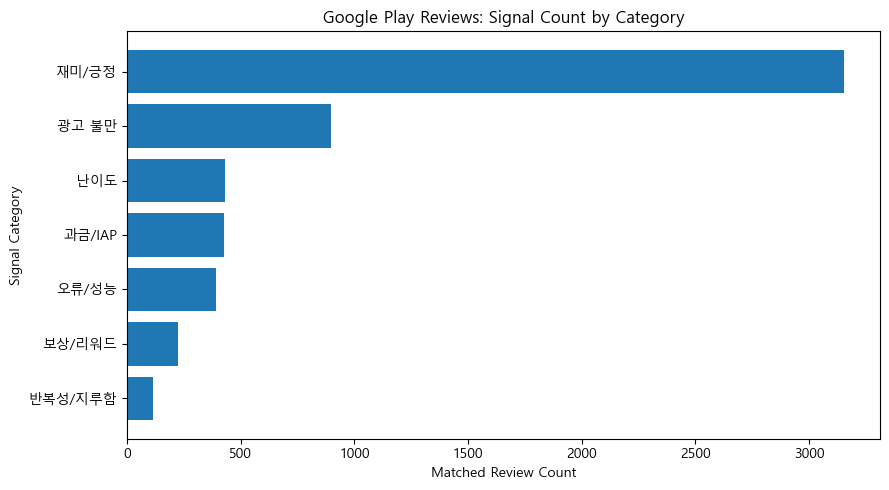

In [8]:
# 10. 앱 메타데이터와 앱별 리뷰 신호 요약 결합

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

app_meta_cols = [
    "app_id",
    "title",
    "developer",
    "genre",
    "score",
    "ratings_count",
    "reviews_count",
    "installs",
    "min_installs",
    "real_installs",
    "free",
    "contains_ads",
    "in_app_purchase",
    "updated",
    "content_rating",
]

available_meta_cols = [col for col in app_meta_cols if col in apps_df.columns]

app_review_meta_summary = app_signal_summary.merge(
    apps_df[available_meta_cols],
    on=["app_id", "title"],
    how="left"
)

display(app_review_meta_summary.head())

app_review_meta_summary.to_csv(
    OUTPUT_TABLE_DIR / "google_play_app_review_meta_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 11. 광고 포함 여부 / 인앱결제 여부별 메타데이터 요약

meta_group_rows = []

if "contains_ads" in app_review_meta_summary.columns:
    for value, group in app_review_meta_summary.groupby("contains_ads", dropna=False):
        meta_group_rows.append({
            "group_type": "contains_ads",
            "group_value": value,
            "app_count": len(group),
            "avg_store_score": group["score"].mean(),
            "avg_review_score_collected": group["avg_review_score"].mean(),
            "avg_ad_complaint_rate": group["ad_complaint_rate"].mean(),
            "avg_review_risk_score": group["review_risk_score"].mean(),
        })

if "in_app_purchase" in app_review_meta_summary.columns:
    for value, group in app_review_meta_summary.groupby("in_app_purchase", dropna=False):
        meta_group_rows.append({
            "group_type": "in_app_purchase",
            "group_value": value,
            "app_count": len(group),
            "avg_store_score": group["score"].mean(),
            "avg_review_score_collected": group["avg_review_score"].mean(),
            "avg_ad_complaint_rate": group["ad_complaint_rate"].mean(),
            "avg_review_risk_score": group["review_risk_score"].mean(),
        })

meta_group_summary_df = pd.DataFrame(meta_group_rows)
display(meta_group_summary_df)

meta_group_summary_df.to_csv(
    OUTPUT_TABLE_DIR / "google_play_app_meta_group_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 12. 시각화 1: 리뷰 신호별 등장 건수

plot_signal_count = signal_summary_df.sort_values("matched_review_count", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_signal_count["display_name"], plot_signal_count["matched_review_count"])
ax.set_title("Google Play Reviews: Signal Count by Category")
ax.set_xlabel("Matched Review Count")
ax.set_ylabel("Signal Category")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "google_play_review_signal_count.png", dpi=150)
plt.show()

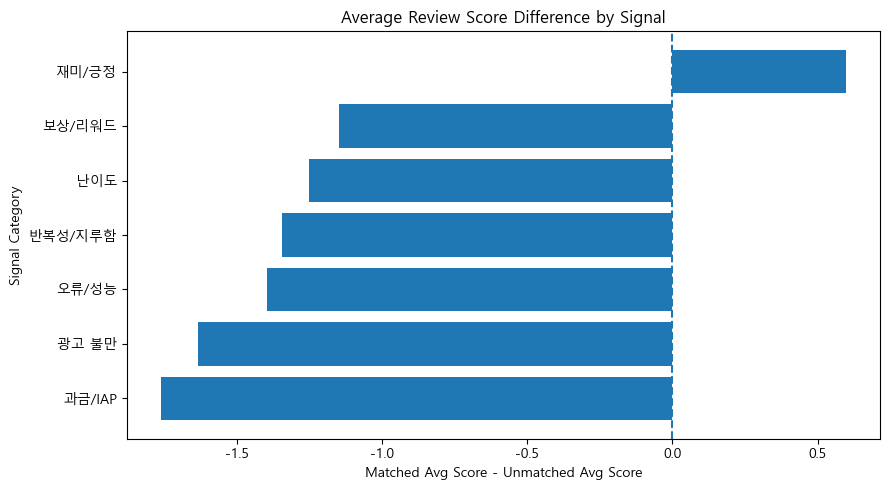

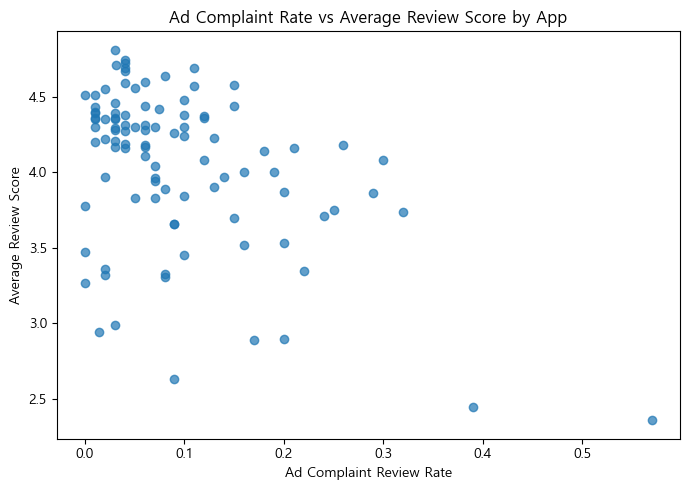

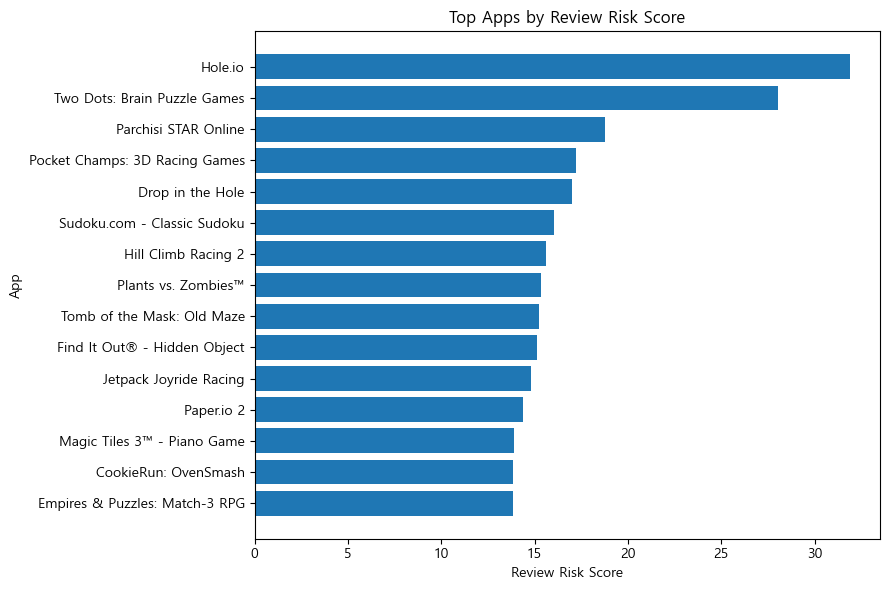

,total_apps,total_reviews,review_apps,avg_review_score,ad_complaint_review_count,ad_complaint_review_rate,ad_complaint_avg_score,non_ad_complaint_avg_score,risk_signal_review_rate
0,100,9761,99,4.064747,896,0.091794,2.579241,4.21489,0.188198


Saved docs:
C:\취준\mobile-game-retention-review-ua-analysis\docs\review_signal_dictionary.md
C:\취준\mobile-game-retention-review-ua-analysis\docs\google_play_review_signal_analysis.md
google_play_review_signal_dictionary.csv exists: True
google_play_review_signal_summary.csv exists: True
google_play_ad_complaint_score_comparison.csv exists: True
google_play_app_review_risk_score.csv exists: True
google_play_app_review_meta_summary.csv exists: True
google_play_app_meta_group_summary.csv exists: True
google_play_review_final_summary.csv exists: True
google_play_review_signal_count.png exists: True
google_play_review_signal_score_diff.png exists: True
google_play_ad_complaint_vs_score.png exists: True
google_play_top_review_risk_apps.png exists: True
review_signal_dictionary.md exists: True
google_play_review_signal_analysis.md exists: True


In [9]:
# 13. 시각화 2: 리뷰 신호별 평균 점수 차이

plot_score_diff = signal_summary_df.sort_values("score_diff_matched_minus_unmatched", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_score_diff["display_name"], plot_score_diff["score_diff_matched_minus_unmatched"])
ax.axvline(0, linestyle="--")
ax.set_title("Average Review Score Difference by Signal")
ax.set_xlabel("Matched Avg Score - Unmatched Avg Score")
ax.set_ylabel("Signal Category")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "google_play_review_signal_score_diff.png", dpi=150)
plt.show()


# 14. 시각화 3: 앱별 광고 불만 비율과 평균 리뷰 점수 관계

plot_app = app_signal_summary.copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(plot_app["ad_complaint_rate"], plot_app["avg_review_score"], alpha=0.7)
ax.set_title("Ad Complaint Rate vs Average Review Score by App")
ax.set_xlabel("Ad Complaint Review Rate")
ax.set_ylabel("Average Review Score")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "google_play_ad_complaint_vs_score.png", dpi=150)
plt.show()


# 15. 시각화 4: 리뷰 리스크 점수 상위 앱

top_risk_apps = app_signal_summary.head(15).sort_values("review_risk_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_risk_apps["title"], top_risk_apps["review_risk_score"])
ax.set_title("Top Apps by Review Risk Score")
ax.set_xlabel("Review Risk Score")
ax.set_ylabel("App")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "google_play_top_review_risk_apps.png", dpi=150)
plt.show()


# 16. 핵심 결과 요약 테이블 생성

final_review_insight_summary = {
    "total_apps": int(apps_df["app_id"].nunique()),
    "total_reviews": int(len(reviews_df)),
    "review_apps": int(reviews_df["app_id"].nunique()),
    "avg_review_score": float(reviews_df["review_score"].mean()),
    "ad_complaint_review_count": int(reviews_df["ad_complaint"].sum()),
    "ad_complaint_review_rate": float(reviews_df["ad_complaint"].mean()),
    "ad_complaint_avg_score": float(reviews_df.loc[reviews_df["ad_complaint"], "review_score"].mean()),
    "non_ad_complaint_avg_score": float(reviews_df.loc[~reviews_df["ad_complaint"], "review_score"].mean()),
    "risk_signal_review_rate": float(reviews_df["has_any_risk_signal"].mean()),
}

final_review_insight_summary_df = pd.DataFrame([final_review_insight_summary])
display(final_review_insight_summary_df)

final_review_insight_summary_df.to_csv(
    OUTPUT_TABLE_DIR / "google_play_review_final_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 17. 문서 저장

review_signal_doc = f"""
# Google Play 게임 리뷰 신호 분석 요약

## 분석 목적
Google Play 캐주얼/하이퍼캐주얼 게임 앱의 메타데이터와 최신 리뷰를 수집해,
앱마켓에서 관찰 가능한 유저 경험 리스크 신호를 분석했다.

## 데이터
- 수집 앱 수: {apps_df["app_id"].nunique():,}개
- 수집 리뷰 수: {len(reviews_df):,}건
- 리뷰가 수집된 앱 수: {reviews_df["app_id"].nunique():,}개

## 리뷰 신호 카테고리
- 광고 불만
- 보상/리워드
- 난이도
- 반복성/지루함
- 오류/성능
- 과금/IAP
- 재미/긍정

## 핵심 결과
- 광고 불만 키워드가 포함된 리뷰 수: {int(reviews_df["ad_complaint"].sum()):,}건
- 광고 불만 리뷰 비율: {reviews_df["ad_complaint"].mean() * 100:.2f}%
- 광고 불만 포함 리뷰 평균 점수: {reviews_df.loc[reviews_df["ad_complaint"], "review_score"].mean():.2f}
- 광고 불만 미포함 리뷰 평균 점수: {reviews_df.loc[~reviews_df["ad_complaint"], "review_score"].mean():.2f}
- 하나 이상의 리스크 신호가 포함된 리뷰 비율: {reviews_df["has_any_risk_signal"].mean() * 100:.2f}%

## 해석
Google Play 리뷰 분석은 개별 UA 캠페인 성과와 직접 연결하지 않았다.
리뷰 데이터는 앱마켓에서 관찰 가능한 유저 경험 신호이며, 캠페인 데이터와 기준 단위가 다르기 때문이다.

다만 리뷰 분석에서 광고 불만, 오류, 반복성 같은 리스크 신호가 낮은 리뷰 점수와 연결될 경우,
모바일 게임 UA 성과를 CPI나 설치 수만으로 판단해서는 안 된다는 시사점을 제공한다.
유입된 유저가 게임 내 광고 경험, 보상 구조, 반복성, 오류 문제로 이탈할 수 있기 때문에,
UA 성과 판단에는 리텐션과 유저 경험 신호를 함께 고려해야 한다.
"""

(DOCS_DIR / "review_signal_dictionary.md").write_text(
    signal_dictionary_df.to_markdown(index=False),
    encoding="utf-8"
)

(DOCS_DIR / "google_play_review_signal_analysis.md").write_text(
    review_signal_doc,
    encoding="utf-8"
)

print("Saved docs:")
print(DOCS_DIR / "review_signal_dictionary.md")
print(DOCS_DIR / "google_play_review_signal_analysis.md")


# 18. 저장 파일 목록 확인

created_files = [
    OUTPUT_TABLE_DIR / "google_play_review_signal_dictionary.csv",
    OUTPUT_TABLE_DIR / "google_play_review_signal_summary.csv",
    OUTPUT_TABLE_DIR / "google_play_ad_complaint_score_comparison.csv",
    OUTPUT_TABLE_DIR / "google_play_app_review_risk_score.csv",
    OUTPUT_TABLE_DIR / "google_play_app_review_meta_summary.csv",
    OUTPUT_TABLE_DIR / "google_play_app_meta_group_summary.csv",
    OUTPUT_TABLE_DIR / "google_play_review_final_summary.csv",
    OUTPUT_FIGURE_DIR / "google_play_review_signal_count.png",
    OUTPUT_FIGURE_DIR / "google_play_review_signal_score_diff.png",
    OUTPUT_FIGURE_DIR / "google_play_ad_complaint_vs_score.png",
    OUTPUT_FIGURE_DIR / "google_play_top_review_risk_apps.png",
    DOCS_DIR / "review_signal_dictionary.md",
    DOCS_DIR / "google_play_review_signal_analysis.md",
]

for file_path in created_files:
    print(file_path.name, "exists:", file_path.exists())